In [5]:
# Cell to calculate all the information to parse the information from the file 
# Need to develop a system to create a new file that's easier and faster to read the data from



import matplotlib.pyplot as plt
import numpy as np
import statistics      
from scipy import stats

# Set global theme settings for plotting
plt.rcParams.update({
    'font.size': 20,          # Set font size
    'lines.linewidth': 3,     # Set default line thickness
    'axes.titlesize': 20,     # Title font size
    'axes.labelsize': 18,     # Axis label font size
    'xtick.labelsize': 14,    # X-tick label font size
    'ytick.labelsize': 14,    # Y-tick label font size
    'grid.color': 'gray',     # Grid color
    'grid.linestyle': '--',   # Grid line style
    'grid.linewidth': 0.5,    # Grid line width
    'legend.fontsize': 16     # Legend font size
})

uds = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8]
all_datasets = [] # stores all the datasets

timesteps = [] # timesteps, 0 to 20,000
original_omegas = []; omegas = []; harmonic_means = []
subtracted_arithmetic_means = []; subtracted_geometric_means = []; selective_deaths = []
arithmetic_means = []; geometric_means = []
wanted = [2, 4, 6, 8]

def parse_files():
    # Purpose: Parses the files by building strings in order to gather all the data from the file
    # 
    # Returns: A list of tuples. (A, B). Let A be the UD associated with the file, and B be the Data from the file. 
    for ud in uds: 
        filename = "/Users/cameronliu/Desktop/Research/sd-0.0025/datafor_relative_tskitstatus_OFF_fixationcalc_OFF_Sb_1.0000_deldist_point_bendist_exponential_mub_0.0000_chromnum_23_N0_2000_mud_" + str(ud) + "_L_200_seed_24_Sd_0.002500/rawdataforNxtimesteps20000popsize2000mutrate" + str(ud) + "chromsize200chromnum23benmutrate0.0000Sb1.0000.txt"
        file_data = []
        with open(filename, "r") as file:
            next(file) # skips the first line
            for line in file: 
                line = line.strip().split(",")
                if len(timesteps) < 20000: # Skips adding after the 0 - 20,000 timesteps
                    timesteps.append(line[0])
                file_data.append(float(line[3]))
        all_datasets.append((ud, file_data))
    return all_datasets

def slice_data():
    timesteps[:] = timesteps[2000:]  # In-place update

    for i in range(len(all_datasets)):
        ud, data = all_datasets[i]
        data = data[2000:]
        all_datasets[i] = (ud, data)


def calculate_harmonic_means(): 
    for info in all_datasets: 
        ud = info[0]; data = info[1]

        subtracted_data = [1 - value for value in data]
        original_omega = statistics.harmonic_mean(subtracted_data)
        
        new_omega = 1 - statistics.harmonic_mean(data)

        harmonic_mean = statistics.harmonic_mean(data)

        original_omegas.append((ud, original_omega))
        omegas.append((ud, new_omega))
        harmonic_means.append((ud, harmonic_mean))

def calculate_geometric_means():
    for ud, data in all_datasets:
        # filter out the non-positive values since geometric mean is undefined for them
        positive_data = [x for x in data if x > 0]
        if not positive_data:
            continue  # skip this dataset if all values are zero or negative
        
        subtracted_mean = 1 - statistics.geometric_mean(positive_data)
        subtracted_geometric_means.append((ud, subtracted_mean))

def calculate_arithmetic_means():
    for ud, data in all_datasets:
        subtracted_arithmetic_mean = 1 - statistics.mean(data)
        subtracted_arithmetic_means.append((ud, subtracted_arithmetic_mean))
        

def moving_average(data, window):
    weights = np.ones(window) / window
    return np.convolve(data, weights, mode='valid')





parse_files()
#slice_data()
calculate_harmonic_means()
calculate_arithmetic_means()
calculate_geometric_means()








In [ ]:
# Cell to calculate the histograms without their transformations 


wanted = (2, 4, 6, 8)

bin_count = 200
for tuple in all_datasets: # in this case, tuple represents (A, B), where A is the UD, and B is the array of Fraction of Selective Deaths
    ud = tuple[0]; dataset = tuple[1]; 
    if ud in wanted: 
        print("ud: " + str(ud))
        plt.figure(figsize=(16, 10))
        plt.title("Histogram of Fraction of Selective Deaths, UD = " + str(ud))
        plt.hist(dataset, bins=bin_count, edgecolor='blue')
        plt.savefig("/Users/cameronliu/Desktop/Research/Untransformed S. Deaths Histograms/" + "sd-0.0025_untransformed_ud-" + str(ud) + "_histogram_bins-" + str(bin_count) + ".png", dpi=300, bbox_inches='tight')


In [ ]:
# Cell to calculate the histograms with their transformations
wanted = (2, 4, 6, 8)


transformed_datasets = []
for tuple in all_datasets: # iterates through all the datasets
    ud = tuple[0]; dataset = tuple[1]
    transformed_data, fitted_lambda = stats.boxcox(dataset)
    transformed_data = stats.boxcox(dataset, fitted_lambda) # gets the transformed data, and the lambda that is dedicated to that dataset
    transformed_datasets.append((ud, transformed_data, fitted_lambda))

bin_count = 200
for tuple in transformed_datasets: # in this case, tuple represents (A, B), where A is the UD, and B is the array of Fraction of Selective Deaths
    ud = tuple[0]; dataset = tuple[1]; fitted_lambda = tuple[2]
    if ud in wanted: 
        print("ud: " + str(ud) + " lamba: " + str(fitted_lambda))
        plt.figure(figsize=(16, 10))
        plt.title("Transformed Histogram of Fraction of Selective Deaths, UD = " + str(ud) + ", " + "Fixed Lambda: " + str(fitted_lambda))
        plt.hist(dataset, bins=bin_count, edgecolor='blue')

        # Save the figure
        plt.savefig("/Users/cameronliu/Desktop/Research/Selective Death Histograms/Transformed Boxcox/" + "sd-0.0025_transformed_ud-" + str(ud) + "_histogram_bins-" + str(bin_count) + ".png", dpi=300, bbox_inches='tight')


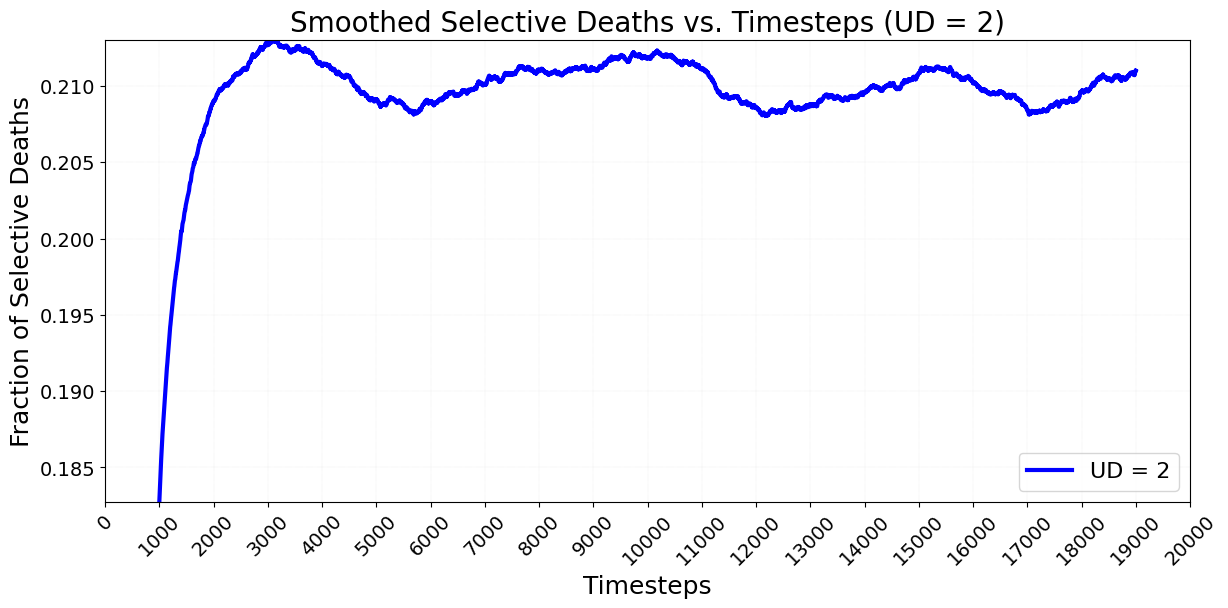

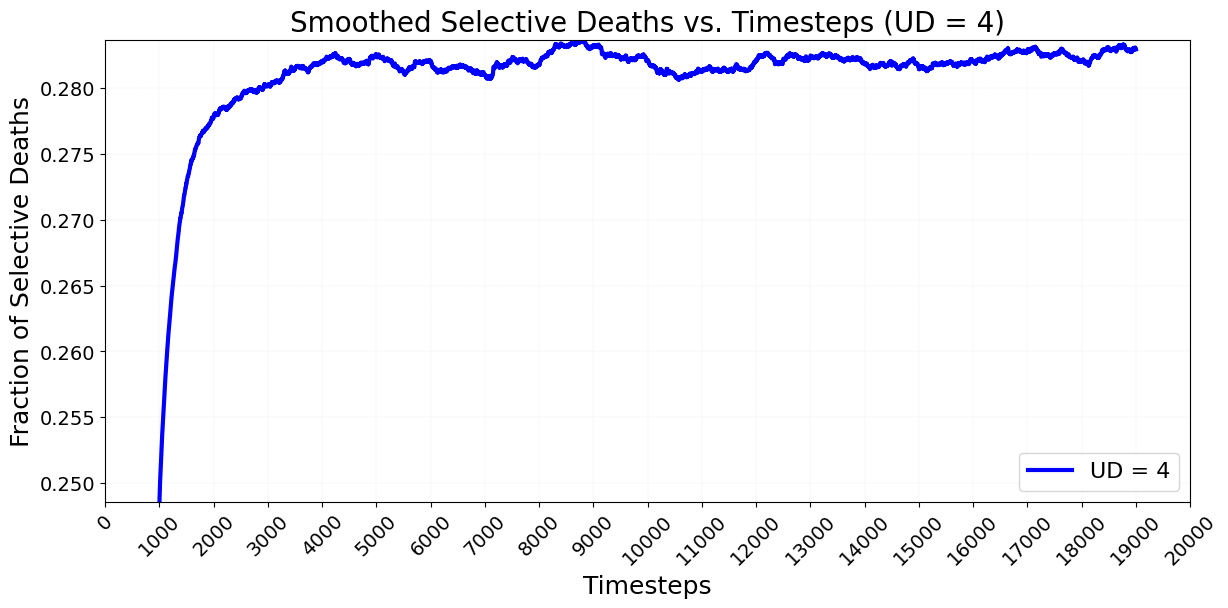

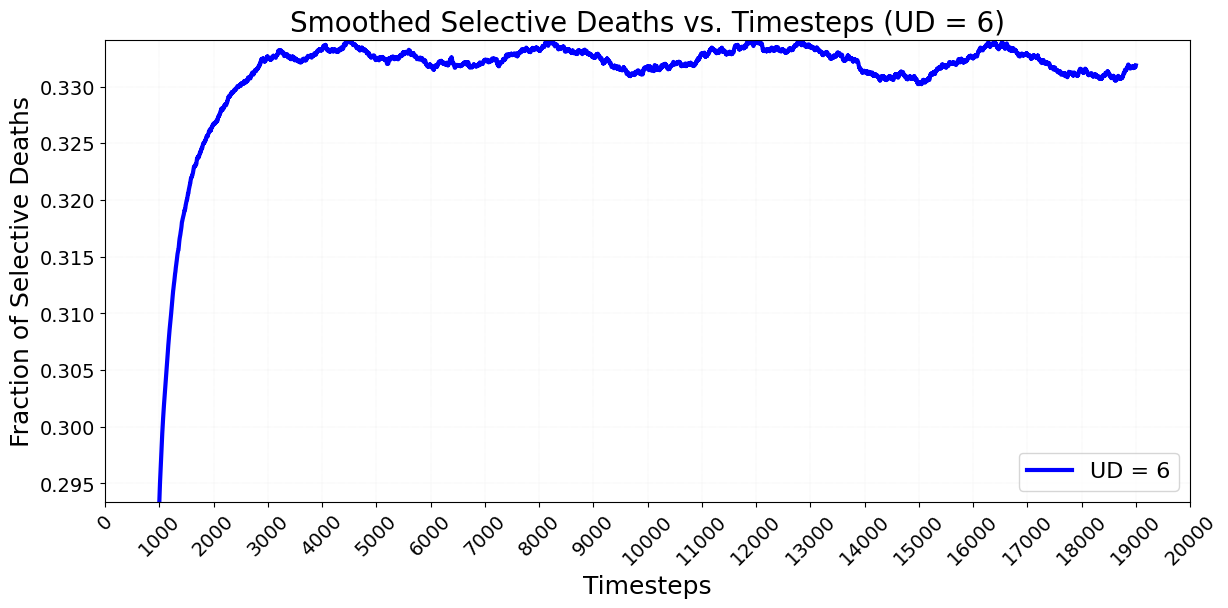

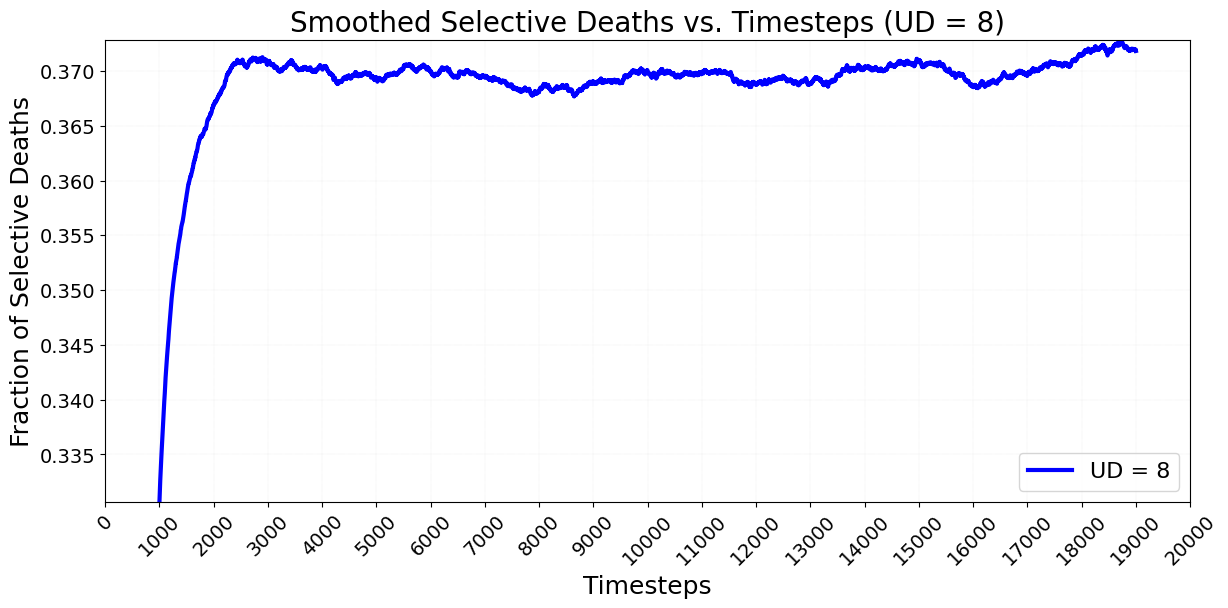

In [7]:
# Cell to calculate the Sel. Deaths vs. Timesteps 

window_size = 2000
start = 0
end = 20000
tick_interval = 1000

for ud, data in all_datasets:
    if ud in wanted:
        smoothed_data = moving_average(data, window=window_size)

        # Align smoothed values with the center of the window
        offset = window_size // 2
        smoothed_timesteps = [int(timesteps[i + offset]) for i in range(len(smoothed_data))]

        # Slice based on visible range
        sliced_data = []
        sliced_timesteps = []
        for t, d in zip(smoothed_timesteps, smoothed_data):
            if start <= t <= end:
                sliced_timesteps.append(t)
                sliced_data.append(d)

        # Set tick marks based on your desired time range
        tick_locs = list(range(start, end + 1, tick_interval))

        # Get full-range y-limits for consistent scaling
        y_min = min(smoothed_data)
        y_max = max(smoothed_data)

        fig = plt.figure(figsize=(14, 6))
        fig.patch.set_facecolor('white')
        ax = fig.gca()
        ax.set_facecolor('white')

        ax.plot(sliced_timesteps, sliced_data, label=f"UD = {ud}", color='blue')
        ax.set_xlabel("Timesteps")
        ax.set_ylabel("Fraction of Selective Deaths")
        ax.set_title(f"Smoothed Selective Deaths vs. Timesteps (UD = {ud})")
        ax.grid(True, linestyle=':', color='lightgray', linewidth=0.3)
        ax.set_xticks(tick_locs)
        ax.set_ylim(y_min, y_max)
        plt.xticks(rotation=45)
        ax.legend()

        plt.savefig(f"/Users/cameronliu/Desktop/Research/Selective Death Graphs/smoothed_sd-0.0025_ud-{ud}_vs_timesteps.png", dpi=300, bbox_inches='tight')
        plt.show()
